## Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


## Dataset: Gross Rent as a Percentage of Household Income in the Past 12 Months

SOURCE: https://data.census.gov/table/ACSDT5Y2021.B25070

DATASET DESCRIPTION

- Title   : Gross Rent as a Percentage of Household Income in the Past 12 Months
- Program : American Community Survey (ACS)
- Universe: Renter-occupied housing units in the United States
- Year    : 2021 (5-Year Estimates, 2017-2021)
- Table ID: B25070
- Source  : U.S. Census Bureau

The dataset captures the distribution of gross rent burden across U.S.
renter-occupied housing units. Each row represents a rent-to-income ratio
bracket (e.g., "Less than 10.0 percent", "50.0 percent or more") along with
a national estimate of how many housing units fall into that bracket and
the associated 90% margin of error (MOE).

Key Notes
- Estimates are based on a sample and subject to sampling variability.
- The MOE represents a 90% confidence interval around each estimate.
- A "Not computed" category exists for units where the ratio could not
  be calculated (e.g., zero or negative income).
- Data reflect OMB metropolitan/micropolitan delineations as of March 2020.
- Urban/rural boundaries are based on Census 2010 definitions.

## Column Descriptions

### Raw Columns (Before Cleaning)

| Column Name | Data Type | Description | Notes |
|---|---|---|---|
| `Label (Grouping)` | object (string) | The rent-to-income ratio bracket label. The first row is the universe total (`Total:`). The middle rows are the nine rent burden brackets (e.g., `Less than 10.0 percent` up to `50.0 percent or more`). The last row is `Not computed`, covering units where the ratio could not be calculated (e.g., zero or negative household income). | Whitespace-padded in raw file; must be stripped. Two rows require special handling: `Total:` (universe denominator) and `Not computed` (excluded from burden analysis). |
| `United States!!Estimate` | object (string) | The ACS 5-year estimate of the number of renter-occupied housing units in the United States that fall into each bracket. Stored as a comma-formatted string in the raw file (e.g., `43,858,831`) and must be cast to integer for analysis. The first row represents the total universe count; all other rows are subsets of this total. | Comma separators must be removed before numeric conversion. Row 0 (`Total:`) is the universe total and should be separated from bracket rows before computing shares. |
| `United States!!Margin of Error` | object (string) | The 90% margin of error (MOE) associated with each estimate, prefixed with a plus-or-minus symbol (e.g., `±146,712`) in the raw file. The MOE defines the confidence interval: the true population value has a 90% probability of falling within [estimate - MOE, estimate + MOE]. A larger MOE relative to the estimate signals lower reliability for that bracket. | The `±` prefix must be removed before numeric conversion. Relative MOE (MOE / Estimate x 100) is a useful data quality flag: values above 30% indicate unstable estimates. |

---

### Cleaned Columns (After Preprocessing)

| Column Name | Data Type | Description |
|---|---|---|
| `label` | object (string) | Cleaned rent-to-income bracket label with leading and trailing whitespace removed. |
| `estimate` | int64 | Number of renter-occupied U.S. housing units in each bracket, as a clean integer. |
| `moe` | int64 | 90% margin of error for the estimate, as a clean integer with the `±` symbol removed. |
| `pct_of_total` | float64 | Each bracket's estimate expressed as a percentage of the total universe (43,858,831 units). Computed as: `estimate / total_units x 100`. |
| `moe_pct` | float64 | The MOE expressed as a percentage of total units. Useful for comparing absolute uncertainty across brackets on a common scale. |
| `rel_moe_pct` | float64 | Relative margin of error: `MOE / estimate x 100`. A data quality indicator -- values above 30% suggest the estimate should be interpreted with caution. |
| `cumulative_pct` | float64 | Running cumulative sum of `pct_of_total` across brackets in order. Reaches 100% only when the `Not Computed` row is included. |
| `cost_burdened` | bool | `True` if the bracket meets the standard HUD cost-burden threshold (gross rent >= 30% of household income). Covers the four highest rent burden brackets. |
| `is_total` | bool | `True` for the universe total row (`Total:`). Used to separate the denominator from the bracket rows during analysis. |
| `is_not_computed` | bool | `True` for the `Not computed` row. These units are excluded from burden share calculations since the ratio could not be determined. |

## Preprocessing of the Dataset

In [2]:
gr_df = pd.read_csv('data/gross_rent_12months.csv')
gr_df

,Label (Grouping),United States!!Estimate,United States!!Margin of Error
0,Total:,"43,858,831","±146,712"
1,Less than 10.0 percent,"1,711,674","±15,382"
2,10.0 to 14.9 percent,"3,701,914","±21,907"
3,15.0 to 19.9 percent,"5,240,201","±24,323"
4,20.0 to 24.9 percent,"5,248,722","±23,937"
5,25.0 to 29.9 percent,"4,739,892","±21,329"
6,30.0 to 34.9 percent,"3,719,857","±20,343"
7,35.0 to 39.9 percent,"2,716,546","±15,929"
8,40.0 to 49.9 percent,"3,684,426","±21,388"
9,50.0 percent or more,"10,048,573","±45,066"


In [4]:
# Inspection of Shape, Columns, Types
print("Shape:", gr_df.shape)
print("\nColumn names:", gr_df.columns.tolist())
print("\nData types:\n", gr_df.dtypes)
print("\nRaw head:\n")
gr_df.head(11)

Shape: (11, 3)

Column names: ['Label (Grouping)', 'United States!!Estimate', 'United States!!Margin of Error']

Data types:
 Label (Grouping)                  object
United States!!Estimate           object
United States!!Margin of Error    object
dtype: object

Raw head:



,Label (Grouping),United States!!Estimate,United States!!Margin of Error
0,Total:,"43,858,831","±146,712"
1,Less than 10.0 percent,"1,711,674","±15,382"
2,10.0 to 14.9 percent,"3,701,914","±21,907"
3,15.0 to 19.9 percent,"5,240,201","±24,323"
4,20.0 to 24.9 percent,"5,248,722","±23,937"
5,25.0 to 29.9 percent,"4,739,892","±21,329"
6,30.0 to 34.9 percent,"3,719,857","±20,343"
7,35.0 to 39.9 percent,"2,716,546","±15,929"
8,40.0 to 49.9 percent,"3,684,426","±21,388"
9,50.0 percent or more,"10,048,573","±45,066"


In [ ]:
# Preprocessing and Cleaning

# Standardize column names
gr_df.columns = ['label', 'estimate_raw', 'moe_raw']

# Strip leading/trailing whitespace from labels
gr_df['label'] = gr_df['label'].str.strip()

# Clean estimate: remove commas, cast to numeric
gr_df['estimate'] = (
    gr_df['estimate_raw']
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Clean MOE: remove '±' and commas, cast to numeric
gr_df['moe'] = (
    gr_df['moe_raw']
    .str.replace('±', '', regex=False)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Flag special / non-standard rows
#     "Total:" is the universe total; "Not computed" is a known missing bucket
gr_df['is_total']       = gr_df['label'].str.lower().str.startswith('total')
gr_df['is_not_computed']= gr_df['label'].str.lower() == 'not computed'

# Drop raw string columns now that we have clean numeric ones
gr_df_clean = gr_df.drop(columns=['estimate_raw', 'moe_raw'])

print("Cleaned dataframe:")
gr_df_clean

Cleaned dataframe:


,label,estimate,moe,is_total,is_not_computed
0,Total:,43858831,146712,True,False
1,Less than 10.0 percent,1711674,15382,False,False
2,10.0 to 14.9 percent,3701914,21907,False,False
3,15.0 to 19.9 percent,5240201,24323,False,False
4,20.0 to 24.9 percent,5248722,23937,False,False
5,25.0 to 29.9 percent,4739892,21329,False,False
6,30.0 to 34.9 percent,3719857,20343,False,False
7,35.0 to 39.9 percent,2716546,15929,False,False
8,40.0 to 49.9 percent,3684426,21388,False,False
9,50.0 percent or more,10048573,45066,False,False


In [ ]:
# Checking Missing Values
print("Null counts per column:")
print(gr_df_clean.isnull().sum())
print("\nAny duplicates?", gr_df_clean.duplicated().any())

Null counts per column:
label              0
estimate           0
moe                0
is_total           0
is_not_computed    0
dtype: int64

Any duplicates? False


In [7]:
# Splitting Info to Analysis

# Total universe count (single row)
total_row  = gr_df_clean[gr_df_clean['is_total']].copy()

# Rent-burden brackets only (excludes Total and Not Computed)
brackets   = gr_df_clean[
    ~gr_df_clean['is_total'] & ~gr_df_clean['is_not_computed']
].copy().reset_index(drop=True)

# Not-computed row
not_comp   = gr_df_clean[gr_df_clean['is_not_computed']].copy()

total_units = int(total_row['estimate'].values[0])

print(f"Total renter-occupied units (universe): {total_units:,}")
print(f"\nBrackets available for analysis: {len(brackets)}")
print(f"Not-computed units: {int(not_comp['estimate'].values[0]):,}")

Total renter-occupied units (universe): 43,858,831

Brackets available for analysis: 9
Not-computed units: 3,047,026


In [8]:
# Metrics Derived

brackets['pct_of_total'] = (brackets['estimate'] / total_units * 100).round(2)
brackets['moe_pct']      = (brackets['moe']      / total_units * 100).round(4)

# Relative margin of error (coefficient of variation proxy)
brackets['rel_moe_pct']  = (brackets['moe'] / brackets['estimate'] * 100).round(2)

# Cumulative share
brackets['cumulative_pct'] = brackets['pct_of_total'].cumsum().round(2)

# Cost-burdened flag: rent >= 30% of income is the standard HUD threshold
brackets['cost_burdened'] = brackets['label'].apply(
    lambda x: True if any(
        t in x for t in ['30.0 to 34.9','35.0 to 39.9','40.0 to 49.9','50.0 percent']
    ) else False
)

print(brackets[['label','estimate','pct_of_total','cumulative_pct',
                 'moe','rel_moe_pct','cost_burdened']].to_string(index=False))

                 label  estimate  pct_of_total  cumulative_pct   moe  rel_moe_pct  cost_burdened
Less than 10.0 percent   1711674          3.90            3.90 15382         0.90          False
  10.0 to 14.9 percent   3701914          8.44           12.34 21907         0.59          False
  15.0 to 19.9 percent   5240201         11.95           24.29 24323         0.46          False
  20.0 to 24.9 percent   5248722         11.97           36.26 23937         0.46          False
  25.0 to 29.9 percent   4739892         10.81           47.07 21329         0.45          False
  30.0 to 34.9 percent   3719857          8.48           55.55 20343         0.55           True
  35.0 to 39.9 percent   2716546          6.19           61.74 15929         0.59           True
  40.0 to 49.9 percent   3684426          8.40           70.14 21388         0.58           True
  50.0 percent or more  10048573         22.91           93.05 45066         0.45           True


In [9]:
# Statistics Summary
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

cost_burdened_units = brackets.loc[brackets['cost_burdened'], 'estimate'].sum()
cost_burdened_pct   = cost_burdened_units / total_units * 100

severely_burdened   = brackets.loc[
    brackets['label'].str.contains('50.0 percent'), 'estimate'
].sum()
severely_burdened_pct = severely_burdened / total_units * 100

not_computed_units  = int(not_comp['estimate'].values[0])
not_computed_pct    = not_computed_units / total_units * 100

print(f"  Universe (total renter-occupied units) : {total_units:>15,}")
print(f"  Cost-burdened (>=30% rent-to-income)  : {cost_burdened_units:>15,}  ({cost_burdened_pct:.1f}%)")
print(f"  Severely burdened (>=50%)             : {int(severely_burdened):>15,}  ({severely_burdened_pct:.1f}%)")
print(f"  Not computed                          : {not_computed_units:>15,}  ({not_computed_pct:.1f}%)")
print(f"\n  Bracket with highest count            : {brackets.loc[brackets['estimate'].idxmax(), 'label']}")
print(f"  Bracket with lowest count             : {brackets.loc[brackets['estimate'].idxmin(), 'label']}")
print(f"\n  Avg MOE across brackets               : {brackets['moe'].mean():>15,.0f}")
print(f"  Avg relative MOE                      : {brackets['rel_moe_pct'].mean():>14.2f}%")
print("=" * 60)

DATASET SUMMARY
  Universe (total renter-occupied units) :      43,858,831
  Cost-burdened (>=30% rent-to-income)  :      20,169,402  (46.0%)
  Severely burdened (>=50%)             :      10,048,573  (22.9%)
  Not computed                          :       3,047,026  (6.9%)

  Bracket with highest count            : 50.0 percent or more
  Bracket with lowest count             : Less than 10.0 percent

  Avg MOE across brackets               :          23,289
  Avg relative MOE                      :           0.56%


## Exploratory Data Analysis

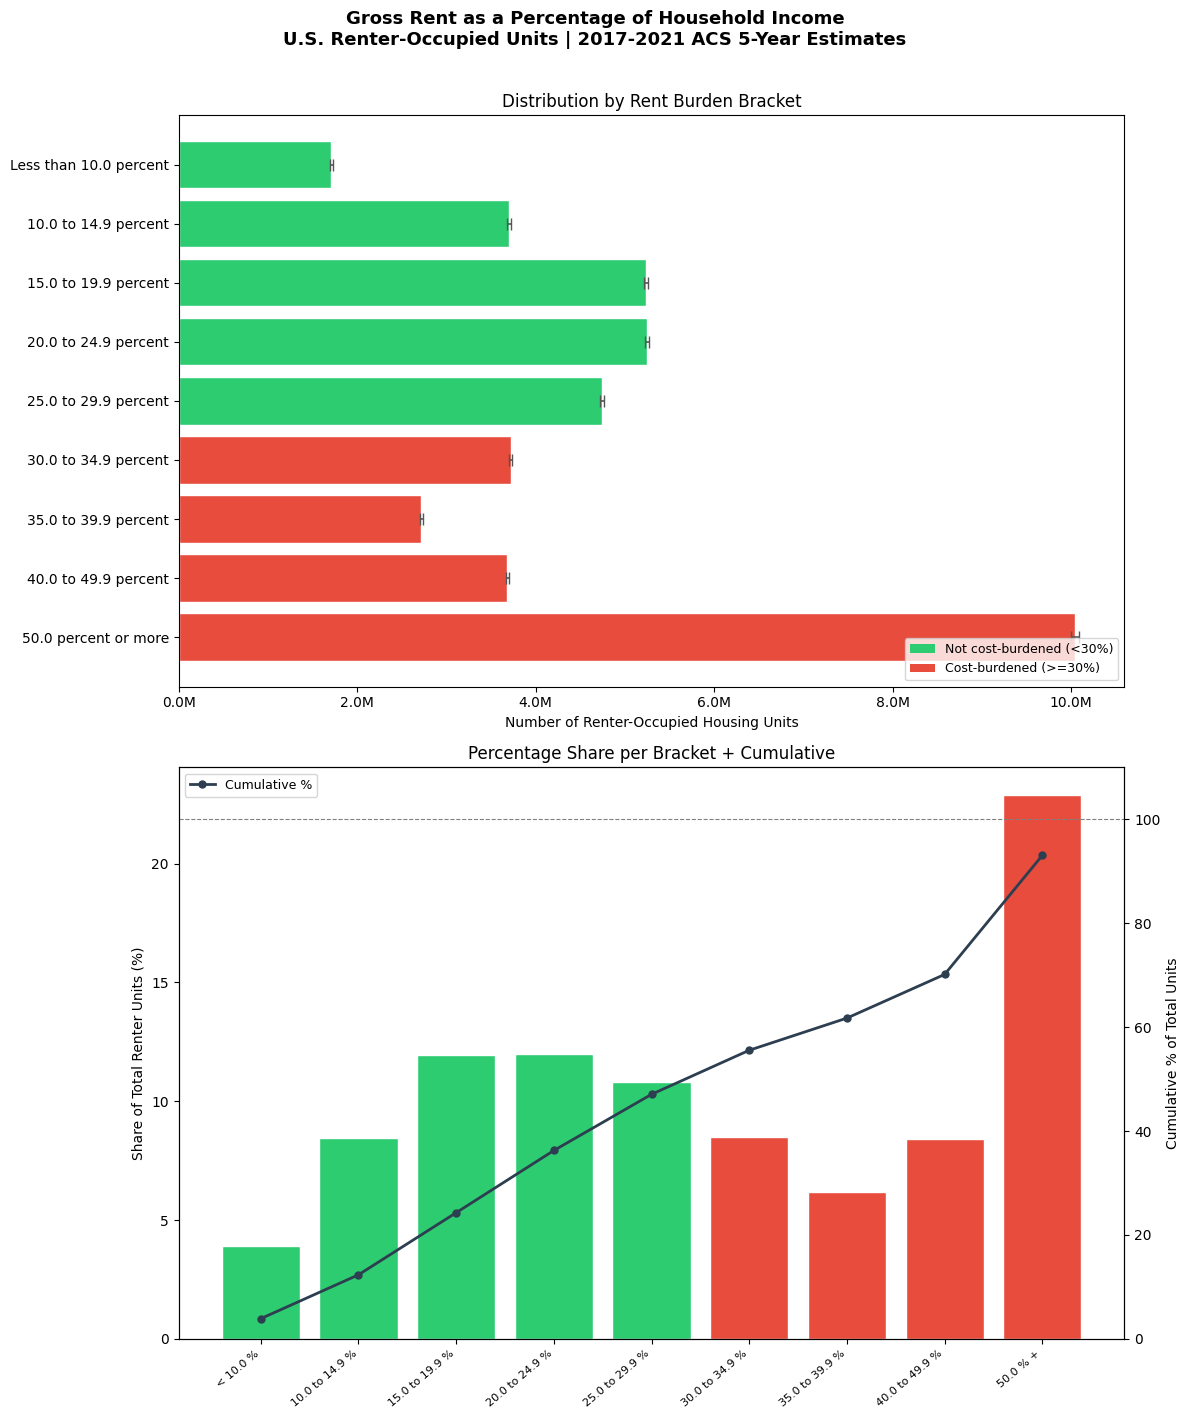

In [12]:
# EDA Visualizations

COLORS_MAIN = ['#2ecc71' if not b else '#e74c3c'
               for b in brackets['cost_burdened']]

fig, axes = plt.subplots(2, 1, figsize=(12, 14))
fig.suptitle(
    "Gross Rent as a Percentage of Household Income\n"
    "U.S. Renter-Occupied Units | 2017-2021 ACS 5-Year Estimates",
    fontsize=13, fontweight='bold', y=1.01
)

# -- Plot 1: Horizontal bar chart with error bars
ax1 = axes[0]
ax1.barh(
    brackets['label'],
    brackets['estimate'],
    xerr=brackets['moe'],
    color=COLORS_MAIN,
    edgecolor='white',
    capsize=4,
    error_kw={'elinewidth': 1.2, 'ecolor': '#555'}
)
ax1.set_xlabel("Number of Renter-Occupied Housing Units")
ax1.set_title("Distribution by Rent Burden Bracket")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax1.invert_yaxis()

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#2ecc71', label='Not cost-burdened (<30%)'),
    Patch(facecolor='#e74c3c', label='Cost-burdened (>=30%)')
]
ax1.legend(handles=legend_els, loc='lower right', fontsize=9)

# -- Plot 2: Percent-of-total with cumulative line
ax2 = axes[1]
ax2.bar(
    range(len(brackets)),
    brackets['pct_of_total'],
    color=COLORS_MAIN,
    edgecolor='white'
)
ax2_twin = ax2.twinx()
ax2_twin.plot(
    range(len(brackets)),
    brackets['cumulative_pct'],
    color='#2c3e50', marker='o', linewidth=2, markersize=5, label='Cumulative %'
)
ax2_twin.axhline(y=100, color='gray', linestyle='--', linewidth=0.8)
ax2_twin.set_ylabel("Cumulative % of Total Units")
ax2_twin.set_ylim(0, 110)

ax2.set_xticks(range(len(brackets)))
ax2.set_xticklabels(
    [l.replace('percent', '%').replace('Less than', '<')
      .replace('or more', '+') for l in brackets['label']],
    rotation=40, ha='right', fontsize=8
)
ax2.set_ylabel("Share of Total Renter Units (%)")
ax2.set_title("Percentage Share per Bracket + Cumulative")
ax2_twin.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

Interpretation:

Plot 1: Distribution by Rent Burden Bracket (Horizontal Bar Chart)

This chart shows the raw count of renter-occupied housing units in each
rent-to-income bracket, with error bars representing the 90% margin of error.
Bars are color-coded: **green** for brackets below the 30% cost-burden
threshold and **red** for brackets at or above it.

**Key takeaways:**
- The **50.0 percent or more** bracket is the single largest bracket with
  **10,048,573 units (22.9% of all renters)**, meaning nearly 1 in 4 renter
  households spends more than half their income on rent alone.
- The **Less than 10.0 percent** bracket is the smallest at only **1,711,674
  units**, suggesting very few renters pay a negligible share of income on rent.
- The distribution is notably **right-skewed toward high burden**: the red
  (cost-burdened) bars collectively account for **46.0% of all renter
  households**, outnumbering the green (not cost-burdened) bars.
- The error bars are visually small relative to each bar's width, which is
  confirmed by the low average relative MOE of **0.56%** -- indicating that
  all estimates are statistically reliable and precise.
- There is a general **decline in counts from the 15.0-19.9% bracket toward
  the 30.0-34.9% bracket**, then a sharp spike back up at the 50.0%+ bracket,
  suggesting a polarized renter population: many paying very manageable rent
  and a large group in severe financial stress.

---

Plot 2: Percentage Share per Bracket and Cumulative Line

This chart shows each bracket's share of the total renter universe as a
percentage (bars), overlaid with a cumulative percentage line (dark line with
circle markers).

**Key takeaways:**
- The **15.0-19.9%** and **20.0-24.9%** brackets have nearly identical shares
  (~12% each), forming the core of the moderate-burden middle group.
- The cumulative line rises steeply through the early green brackets but
  **does not cross the 50% mark until around the 25.0-29.9% bracket**,
  meaning the majority of renters fall below the cost-burden threshold when
  looking at individual brackets -- yet collectively the cost-burdened group
  dominates at 46.0%.
- The **sharp jump in the cumulative line at the last red bar (50.0%+)**
  reflects just how large that bracket is relative to the others: it alone
  adds nearly 23 percentage points to the cumulative total.
- The cumulative line does not reach 100% on this chart because the **Not
  computed** category (6.9%, or 3,047,026 units) is excluded from the bracket
  analysis, as the rent-to-income ratio could not be determined for those units.

---

Overall Interpretation

Taken together, both charts paint a clear picture of a **deeply rent-burdened
renter population in the United States**. Nearly half of all renter households
(46.0%) are cost-burdened by the standard HUD definition of spending 30% or
more of income on gross rent, and almost 1 in 4 (22.9%) are severely burdened
at 50% or more. The distribution is not gradual -- it is polarized, with a
large cluster of moderate-burden renters in the 15-25% range and an even
larger concentration at the extreme high end (50%+), with relatively few
renters in the middle ground between 30-49%. The high data quality (avg
relative MOE of 0.56%) means these patterns reflect real structural conditions
and are not artifacts of sampling variability.

## Key Takeaway

The data reveals a severe and widespread affordability crisis in American rental housing. Nearly half of all renter households (46%) are cost-burdened, spending 30% or more of their income on rent, and the 50%+ bracket is the single largest group in the entire dataset, meaning extreme rent burden is the most common single experience among renters. The distribution is polarized: renters tend to cluster either in the comfortable low-burden range or at the severe high end, with relatively few in the middle ground between 30-49%. Additionally, nearly 3 million units could not be assigned a rent-to-income ratio at all, suggesting the true scale of housing stress is likely undercounted. Overall, this dataset makes clear that unaffordable rent is not a fringe condition but a structural reality for a large share of the American renter population.

## Dataset: Median Gross Rent as a Percentage of Household Income in the Past 12 Months (Dollars)

SOURCE: https://data.census.gov/table/ACSDT5Y2022.B25071

DATASET DESCRIPTION
Title   : Median Gross Rent as a Percentage of Household Income (Past 12 Months)
Program : American Community Survey (ACS)
Universe: Renter-occupied housing units paying cash rent in the United States
Year    : 2022 (5-Year Estimates, 2018-2022)
Table ID: B25071
Source  : U.S. Census Bureau

This dataset contains a single summary statistic: the national median gross
rent as a percentage of household income. Unlike Table B25070 (which shows
the full distribution across brackets), this table collapses the entire
distribution into one representative value. The universe is slightly narrower
than B25070, covering only units paying cash rent (excluding rent-free units).

Key Notes
- The estimate is the median, not the mean, making it resistant to extreme
  values at either end of the distribution.
- The MOE represents a 90% confidence interval around the median estimate.
- A median of 30.0% sits exactly at the HUD cost-burden threshold, meaning
  at least half of all cash-rent paying renter households are cost-burdened.
- Data reflect OMB delineations as of March 2020 and urban/rural boundaries
  based on 2020 Census definitions.

## Column Descriptions

### Raw Columns (Before Cleaning)

| Column Name | Data Type | Description | Notes |
|---|---|---|---|
| `Label (Grouping)` | object (string) | Describes the single statistic reported: the national median gross rent as a percentage of household income. | Only one data row exists in this table. No bracket groupings are present. |
| `United States!!Estimate` | object (string) | The median rent-to-income ratio across all U.S. renter-occupied housing units paying cash rent, expressed as a percentage (e.g., `30.0`). | Stored as a float-formatted string. No comma formatting since the value is a percentage, not a count. |
| `United States!!Margin of Error` | object (string) | The 90% margin of error for the median estimate, prefixed with `±` (e.g., `±0.1`). Defines the confidence interval as [estimate - MOE, estimate + MOE]. | The `±` prefix must be removed before numeric conversion. The relative MOE here is very low (0.33%), indicating a highly reliable estimate. |

---

### Cleaned Columns (After Preprocessing)

| Column Name | Data Type | Description |
|---|---|---|
| `label` | object (string) | Cleaned description of the statistic with leading and trailing whitespace removed. |
| `estimate` | float64 | The median gross rent as a percentage of household income, as a clean float. A value of 30.0 means the typical renter spends exactly 30% of income on rent. |
| `moe` | float64 | The 90% margin of error for the median estimate, as a clean float with the `±` symbol removed. |
| `ci_lower` | float64 | Lower bound of the 90% confidence interval, computed as `estimate - moe`. |
| `ci_upper` | float64 | Upper bound of the 90% confidence interval, computed as `estimate + moe`. |

## Preprocessing of the Dataset

In [14]:
mgr_df = pd.read_csv('data/median_gross_rent_12months.csv')
mgr_df

,Label (Grouping),United States!!Estimate,United States!!Margin of Error
0,Median gross rent as a percentage of household...,30.0,±0.1


In [15]:
# Shape, Columns, Dtypes
print("Shape:", mgr_df.shape)
print("\nColumn names:", mgr_df.columns.tolist())
print("\nData types:\n", mgr_df.dtypes)

Shape: (1, 3)

Column names: ['Label (Grouping)', 'United States!!Estimate', 'United States!!Margin of Error']

Data types:
 Label (Grouping)                   object
United States!!Estimate           float64
United States!!Margin of Error     object
dtype: object


In [16]:
# Preprocessing and Cleaning

# Standardize column names
mgr_df.columns = ['label', 'estimate_raw', 'moe_raw']

# Strip whitespace from label
mgr_df['label'] = mgr_df['label'].str.strip()

# Clean estimate: cast to float (median percentage, not a count)
mgr_df['estimate'] = pd.to_numeric(mgr_df['estimate_raw'], errors='coerce')

# Clean MOE: remove '±', cast to float
mgr_df['moe'] = (
    mgr_df['moe_raw']
    .str.replace('±', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Compute confidence interval bounds
mgr_df['ci_lower'] = (mgr_df['estimate'] - mgr_df['moe']).round(1)
mgr_df['ci_upper'] = (mgr_df['estimate'] + mgr_df['moe']).round(1)

# Drop raw string columns
mgr_df_clean = mgr_df.drop(columns=['estimate_raw', 'moe_raw'])

print("Cleaned dataframe:")
mgr_df_clean

Cleaned dataframe:


,label,estimate,moe,ci_lower,ci_upper
0,Median gross rent as a percentage of household...,30.0,0.1,29.9,30.1


In [17]:
# Missing Values
print("Null counts:\n", mgr_df_clean.isnull().sum())
print("\nAny duplicates?", mgr_df_clean.duplicated().any())

Null counts:
 label       0
estimate    0
moe         0
ci_lower    0
ci_upper    0
dtype: int64

Any duplicates? False


In [18]:
# Statistics Summary
est  = mgr_df_clean['estimate'].values[0]
moe  = mgr_df_clean['moe'].values[0]
low  = mgr_df_clean['ci_lower'].values[0]
high = mgr_df_clean['ci_upper'].values[0]

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"  Median rent-to-income ratio : {est}%")
print(f"  Margin of error (90% CI)    : +/- {moe}%")
print(f"  Confidence interval         : [{low}%, {high}%]")
print(f"  HUD cost-burden threshold   : 30.0%")
print(f"  At or above threshold?      : {'Yes' if est >= 30.0 else 'No'}")
print(f"  Relative MOE                : {round(moe / est * 100, 2)}%")
print("=" * 60)

DATASET SUMMARY
  Median rent-to-income ratio : 30.0%
  Margin of error (90% CI)    : +/- 0.1%
  Confidence interval         : [29.9%, 30.1%]
  HUD cost-burden threshold   : 30.0%
  At or above threshold?      : Yes
  Relative MOE                : 0.33%


# Key Takeaways
The national median gross rent-to-income ratio sits at exactly 30.0%, meaning that by definition at least half of all U.S. renter households paying cash rent are cost-burdened under the standard HUD threshold. The confidence interval of [29.9%, 30.1%] is exceptionally tight, confirming this is not a borderline statistical artifact but a precise and reliable estimate of the typical renter's financial reality. Paired with the findings from Table B25070, where 46% of renters are cost-burdened and the 50%+ bracket is the single largest group, this median tells us that cost-burden is not being driven by a small pocket of extreme outliers but is instead the central tendency of the entire renter population. Together, these two datasets make a statistically strong case that unaffordable rent has become the baseline condition for American renters, not an exception.